# Review Sentiment & Rating Modeling

Two models, and one important question about the second one.

1. **Sentiment classifier** - TF-IDF + Logistic Regression over review text.
2. **Rating model** - gradient boosting over engineered features, explained with SHAP.

The question: the rating model looks accurate, but *is it actually predicting anything?* Section 4 runs the ablation that answers it, and the answer changes how the model should be described.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.models import rating_predictor, sentiment  # noqa: E402

sns.set_theme(style="whitegrid")
PROCESSED = Path.cwd().parent / "data" / "processed"

train = pd.read_parquet(PROCESSED / "train_features.parquet")
test = pd.read_parquet(PROCESSED / "test_features.parquet")
print(f"Train: {len(train):,}   Test: {len(test):,}")

Train: 23,892   Test: 15,053


## 1. Sentiment classification

Labels are derived from the star rating: 1-2 = negative, 3 = neutral, 4-5 = positive.

Because the ratings are so positive-skewed, **raw accuracy is close to useless here** - a model that blindly predicts "positive" for every review already scores ~80%. Any accuracy figure near that number is indistinguishable from doing nothing.

So we train with `class_weight="balanced"` and judge the model on **macro F1 and per-class recall**, which are the metrics that actually change when the minority classes are handled well.

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report  # noqa: E402
from sklearn.model_selection import train_test_split  # noqa: E402

text = (train["review_title"].fillna("") + " " + train["review_text"].fillna("")).str.strip()
labels = train["rating"].apply(sentiment.rating_to_label)

x_tr, x_te, y_tr, y_te = train_test_split(
    text, labels, test_size=0.15, random_state=42, stratify=labels
)
pipeline = sentiment.build_pipeline().fit(x_tr, y_tr)
preds = pipeline.predict(x_te)

print(classification_report(y_te, preds))

majority_baseline = (y_te == "positive").mean()
print(f"Always-predict-positive baseline accuracy: {majority_baseline:.3f}")

              precision    recall  f1-score   support

    negative       0.60      0.68      0.64       379
     neutral       0.29      0.41      0.34       334
    positive       0.94      0.88      0.91      2871

    accuracy                           0.81      3584
   macro avg       0.61      0.66      0.63      3584
weighted avg       0.85      0.81      0.83      3584

Always-predict-positive baseline accuracy: 0.801


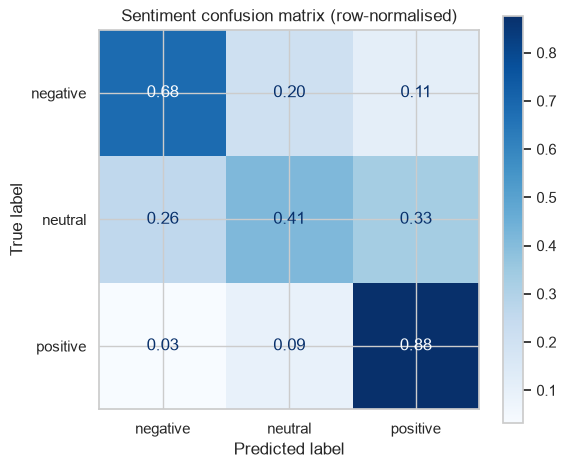

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te, preds, normalize="true", cmap="Blues", ax=ax, values_format=".2f"
)
ax.set_title("Sentiment confusion matrix (row-normalised)")
plt.tight_layout()
plt.show()

**Findings:**

- **Accuracy is a trap here.** The model scores 0.81; always predicting "positive" scores 0.80. On that metric alone the model looks worthless.
- **The real gain is on the minority classes.** The always-positive baseline has *zero* recall on negative reviews - it never flags an unhappy customer. This model recovers **68% of negative reviews** at 0.60 precision (F1 0.64), and macro F1 is 0.63 vs 0.30 for the baseline. For the actual business use case - surfacing dissatisfied customers - that difference is the entire value.
- **Neutral (3-star) is the weak class** (F1 0.34), and that is substantive rather than a modeling failure: 3-star reviews genuinely mix praise and complaint, so their vocabulary overlaps both neighbours. Most of the confusion is neutral↔positive - adjacent classes, not sign errors.

This is why the metric has to be chosen before the model is judged. Reporting "81% accurate" would have been technically true and completely misleading.

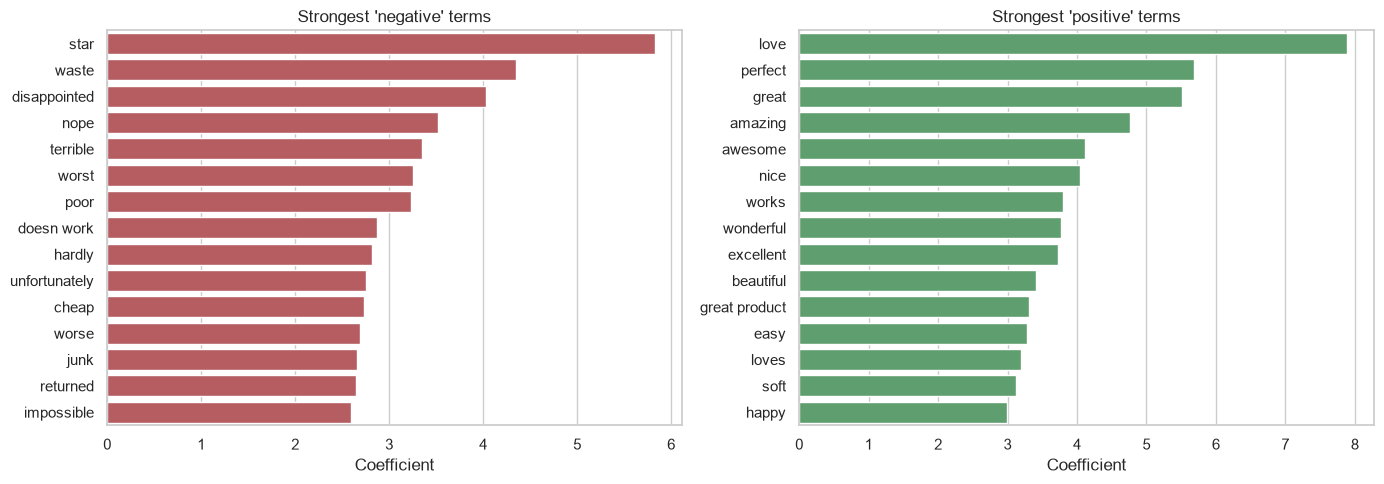

In [4]:
vectorizer = pipeline.named_steps["tfidf"]
classifier = pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, ["negative", "positive"]):
    idx = list(classifier.classes_).index(label)
    coefs = classifier.coef_[idx]
    top = np.argsort(-coefs)[:15]
    sns.barplot(x=coefs[top], y=feature_names[top], ax=ax,
                color="#C44E52" if label == "negative" else "#55A868")
    ax.set_title(f"Strongest '{label}' terms")
    ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

**Sanity check passed:** the learned vocabulary is semantically sensible - the model keyed on genuine opinion words rather than artefacts, which is what we want before trusting its output as a downstream feature.

## 2. Rating model

Gradient boosting over six engineered features. The correct baseline on a skewed rating distribution is *predicting the global mean* - beating that is the bar.

In [5]:
model = rating_predictor.load()
y_test = test["rating"].to_numpy()
test_preds = model.predict(test[rating_predictor.FEATURE_COLUMNS])

global_mean = train["rating"].mean()
baseline_rmse = np.sqrt(np.mean((y_test - global_mean) ** 2))
model_rmse = np.sqrt(np.mean((y_test - test_preds) ** 2))

print(f"Baseline (global mean) test RMSE: {baseline_rmse:.3f}")
print(f"Model test RMSE:                  {model_rmse:.3f}")
print(f"Improvement:                      {(1 - model_rmse / baseline_rmse):.1%}")

Baseline (global mean) test RMSE: 1.309
Model test RMSE:                  0.829
Improvement:                      36.7%


## 3. Explainability - which features drive predictions?

Max additivity error: 1.09e-14  (should be ~0)


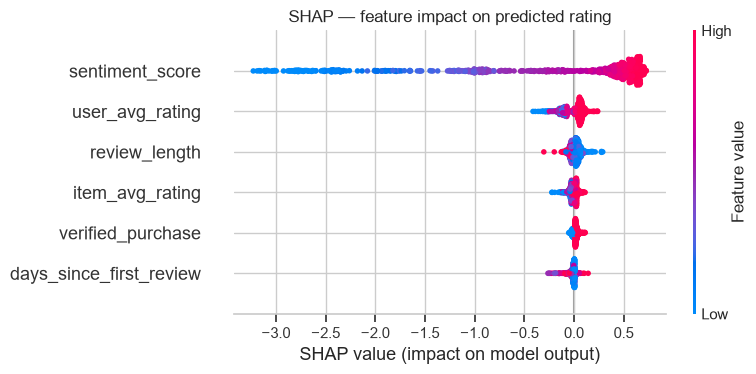

In [6]:
import shap  # noqa: E402

# TreeExplainer with no background dataset = exact tree-path-dependent SHAP.
# (Passing a background sample switches to an approximate interventional method that
# fails SHAP's own additivity check on this model.)
explainer = rating_predictor.build_explainer(model)
sample = test[rating_predictor.FEATURE_COLUMNS].sample(1000, random_state=0)
shap_values = explainer(sample)

additivity_error = abs(
    shap_values.values.sum(1) + shap_values.base_values - model.predict(sample)
).max()
print(f"Max additivity error: {additivity_error:.2e}  (should be ~0)")

shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP - feature impact on predicted rating")
plt.tight_layout()
plt.show()

**Finding:** `sentiment_score` dominates - its impact dwarfs every other feature. That is the clue that motivates the next section.

## 4. The ablation that reframes this model

`sentiment_score` and `review_length` are both derived from **the review text itself**. But think about *when* that text exists: a customer writes their review at the same moment they choose their star rating.

So if we wanted to predict a rating *before* the customer reviewed a product - the genuinely useful business case - those two features would not be available. The honest test is to retrain without them.

In [7]:
ablation = rating_predictor.run_feature_ablation(train, test)
ablation

,feature_set,test_rmse,test_mae
0,global mean (baseline),1.3087,1.0264
1,pre-review features only,1.2645,0.9607
2,review text only (sentiment),0.8394,0.5526
3,all features,0.8238,0.5239


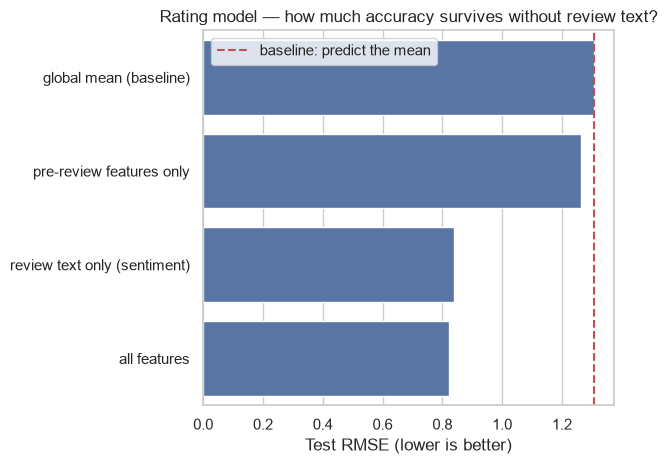

In [8]:
ax = sns.barplot(data=ablation, y="feature_set", x="test_rmse", color="#4C72B0")
ax.axvline(ablation.loc[ablation["feature_set"] == "global mean (baseline)", "test_rmse"].iloc[0],
           color="#C44E52", linestyle="--", label="baseline: predict the mean")
ax.set_title("Rating model - how much accuracy survives without review text?")
ax.set_xlabel("Test RMSE (lower is better)")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

**The finding that matters:**

- With review-text features: **RMSE ≈ 0.82** - a large improvement over the 1.31 baseline.
- Using *only* the sentiment score: **RMSE ≈ 0.84** - essentially the whole model.
- **Pre-review features only** (no text): **RMSE ≈ 1.26** vs a 1.31 baseline - a ~4% improvement, i.e. almost nothing.

So the headline "37% better than baseline" is real, but it does **not** mean we can predict how a customer will rate a product. It means: *given what someone wrote, we can infer the star rating they attached to it.* Nearly all the signal is the review text restating the rating in words.

**This changes what the model is for.** It is not a preference-prediction model. It is a **rating-inference model**, and that is genuinely useful for:

- imputing ratings for feedback that arrives without stars (support tickets, social mentions, free-text surveys);
- flagging **rating/text mismatch** - a 5-star rating attached to angry text is a signal of a mistaken click, review manipulation, or a confused rating scale.

Shipping it as "predicts what a customer will rate a product" would be wrong, and the ablation is what surfaced that. Reporting the headline number alone would have hidden it.

## Summary

| Model | Headline number | What it actually means |
|---|---|---|
| Sentiment classifier | 0.81 accuracy | Misleading - the always-positive baseline scores 0.80. The real result is macro F1 0.63 vs 0.30, and 68% recall on negative reviews vs 0% |
| Rating model (all features) | RMSE 0.82 vs 1.31 baseline | Real, but driven almost entirely by review text |
| Rating model (pre-review only) | RMSE 1.26 vs 1.31 baseline | Cannot predict ratings before the review exists |

Both models needed a baseline comparison to be interpreted correctly, and in both cases the honest reading is different from the headline number.

Next: `03_recommender.ipynb`, where the same discipline overturns a much bigger assumption.